Mirza Fathi Taufiqurrahman
5026231105


In [2]:
!pip install google-play-scraper
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00


In [5]:
from google_play_scraper import Sort, reviews_all
import pandas as pd

# Function to scrape reviews
def scrape_reviews(app_id):
    reviews = reviews_all(
        app_id,
        sleep_milliseconds=0,  # Time to sleep between requests
        lang='id',  # Language of reviews
        country='id',  # Country of reviews
        sort=Sort.NEWEST  # Sort reviews by newest
    )

    # Extract relevant fields
    data = {
        'created_at': [review['at'] for review in reviews],
        'score': [review['score'] for review in reviews],
        'content': [review['content'] for review in reviews],
        'thumbsUpCount': [review['thumbsUpCount'] for review in reviews]
    }

    # Create DataFrame
    df_reviews = pd.DataFrame(data)
    return df_reviews

# Example usage
app_id = 'com.hm.gillcaptital'  # Replace with the actual app ID
df_reviews = scrape_reviews(app_id)
df_reviews.to_csv('hnm.csv', index=True)
print(df_reviews)

              created_at  score  \
0    2026-03-26 22:48:28      1   
1    2026-03-05 01:07:34      1   
2    2026-03-04 14:48:04      1   
3    2026-03-04 10:24:31      5   
4    2026-02-10 03:57:38      3   
...                  ...    ...   
2025 2019-11-19 13:53:37      1   
2026 2019-10-04 21:17:57      3   
2027 2019-09-26 11:44:17      2   
2028 2019-09-25 16:39:19      5   
2029 2019-09-15 11:52:38      5   

                                                content  thumbsUpCount  
0     pengiriman lama kali bisa sampai 10 hari lebih...              0  
1                                   apk lemot bgt buset              0  
2                        lu mau internet sekencang apa?              0  
3        barangnya pas dihati , harga nya pas di dompet              1  
4     kenapa susah mau mau isi tanggal lahir juga, a...              0  
...                                                 ...            ...  
2025  Lemod dan tergembel gabisa di akses setelahh d...             

/tmp/ipykernel_18349/950944504.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')


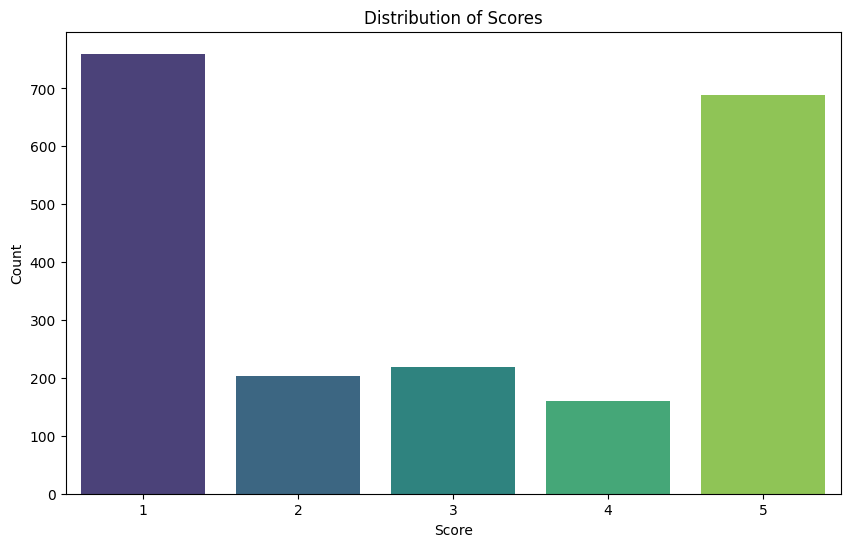

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analisis deskriptif untuk kolom 'score'
score_counts = df_reviews['score'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

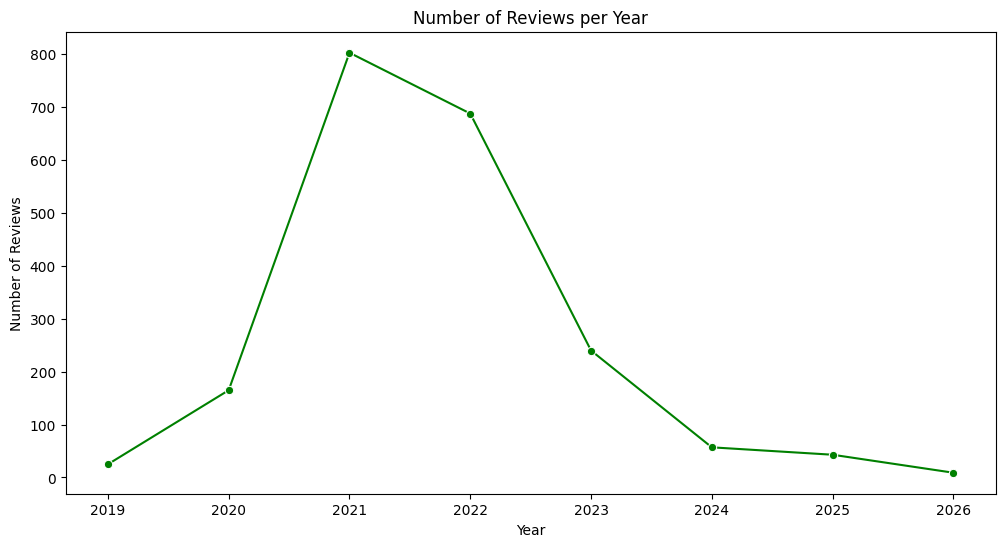

In [7]:
df_reviews['created_at'] = pd.to_datetime(df_reviews['created_at'])
df_reviews['year'] = df_reviews['created_at'].dt.year
year_counts = df_reviews['year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

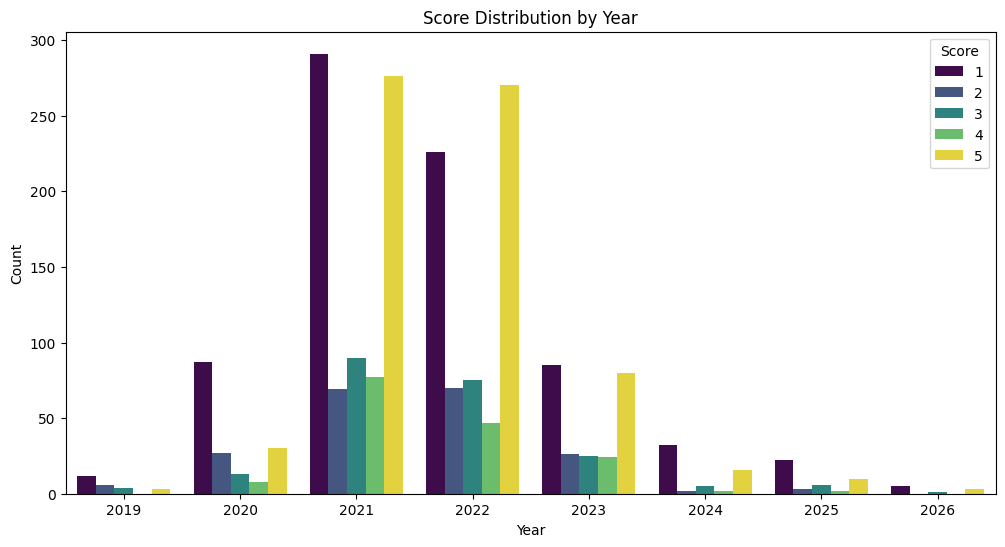

In [8]:
# Cross tabulasi antara 'year' dan 'score'
plt.figure(figsize=(12, 6))
sns.countplot(x='year', hue='score', data=df_reviews, palette='viridis')
plt.title('Score Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Score')
plt.show()

In [11]:
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

# Download stopwords if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

# Get the list of stopwords in Indonesian
stop_words = set(stopwords.words('indonesian'))

# Define a simple dictionary for common informal Indonesian words/abbreviations
informal_to_formal = {
    'yg': 'yang',
    'ga': 'tidak',
    'gak': 'tidak',
    'bgt': 'banget',
    'udh': 'sudah',
    'udah': 'sudah',
    'bikin': 'membuat',
    'gk': 'tidak',
    'kalo': 'kalau',
    'bgus': 'bagus',
    'aja': 'saja',
    'jd': 'jadi',
    'krn': 'karena',
    'dg': 'dengan',
    'utk': 'untuk',
    'tdk': 'tidak',
    'dr': 'dari',
    'kpn': 'kapan',
    'hrs': 'harus',
    'klo': 'kalau',
    'dgn': 'dengan',
    'sampe': 'sampai',
    'smpe': 'sampai',
    'kualitasnya': 'kualitas',
    'lemot': 'lambat',
    'apk': 'aplikasi',
    'pdhl': 'padahal',
    'bnyk': 'banyak',
    'ktnya': 'katanya',
    'blm': 'belum',
    'smpai': 'sampai',
    'trs': 'terus',
    'skrg': 'sekarang',
    'brg': 'barang',
    'kyk': 'kayak',
    'dn': 'dan',
    'bgs': 'bagus',
    'sy': 'saya',
    'udh': 'sudah',
    'dn': 'dan',
    'gpp': 'tidak apa-apa'
}

# Function to preprocess text including removing stopwords, punctuation, numbers, and handling informal words
def preprocess_text(text):
    text = str(text).lower() # Convert to lowercase and ensure it's a string

    # Replace informal words/abbreviations
    words = text.split()
    processed_words = []
    for word in words:
        if word in informal_to_formal:
            processed_words.append(informal_to_formal[word])
        else:
            processed_words.append(word)
    text = ' '.join(processed_words)

    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers, keep only letters and spaces
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words and len(word) > 1] # Remove stopwords and single characters
    return ' '.join(filtered_words)

# Filter positive and negative reviews
positive_reviews = df_reviews[df_reviews['score'] >= 4]['content'].dropna()
negative_reviews = df_reviews[df_reviews['score'] <= 3]['content'].dropna()

# Combine all positive and negative reviews into single strings and preprocess
positive_text = ' '.join(positive_reviews.apply(preprocess_text))
negative_text = ' '.join(negative_reviews.apply(preprocess_text))

# Generate word clouds
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

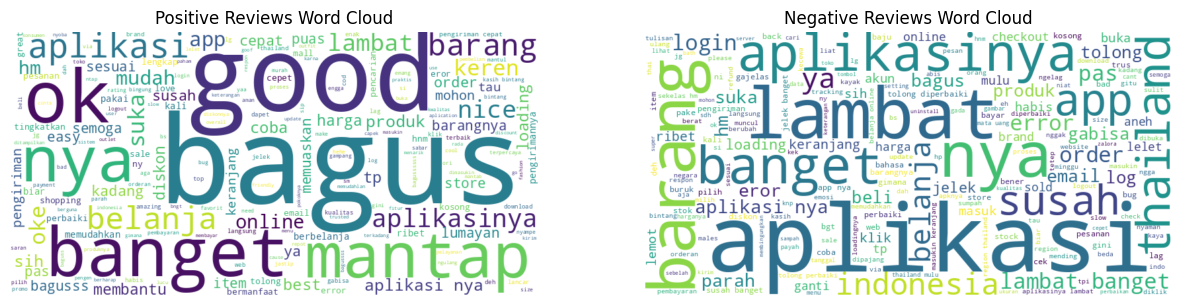

In [12]:
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Reviews Word Cloud')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Reviews Word Cloud')
plt.axis('off')

plt.show()